Gathering historical data using yfinance package first.

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import yfinance as yf
import matplotlib.pyplot as plt

start_date = '2023-01-03'
end_date = '2026-2-23'

stock = "INTC"
index = "SPY"

# Downloading data
stock_data = yf.download(stock, start=start_date, end=end_date)
index_data = yf.download(index, start=start_date, end=end_date)

stock_data.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INTC,INTC,INTC,INTC,INTC
Date,,,,,
2023-01-03,25.775145,26.102999,25.428006,26.083713,31308000
2023-01-04,26.691210,26.922636,26.189785,26.430854,37665200
2023-01-05,26.575495,26.787637,26.401924,26.459782,33552600
2023-01-06,27.703703,27.800131,26.401927,26.932281,31788600
2023-01-09,28.262983,28.802980,27.809773,27.809773,37493200


In [3]:
# Log returns calculation
stock_log_ret = stock_data['Close'].apply(lambda x: np.log(x)).diff()
index_log_ret = index_data['Close'].apply(lambda x: np.log(x)).diff()

# Drop first row which will be nan
stock_log_ret = stock_log_ret.dropna()
index_log_ret = index_log_ret.dropna()

stock_log_ret.head()

Ticker,INTC
Date,
2023-01-04,0.034924
2023-01-05,-0.004345
2023-01-06,0.041577
2023-01-09,0.019987
2023-01-10,0.004425


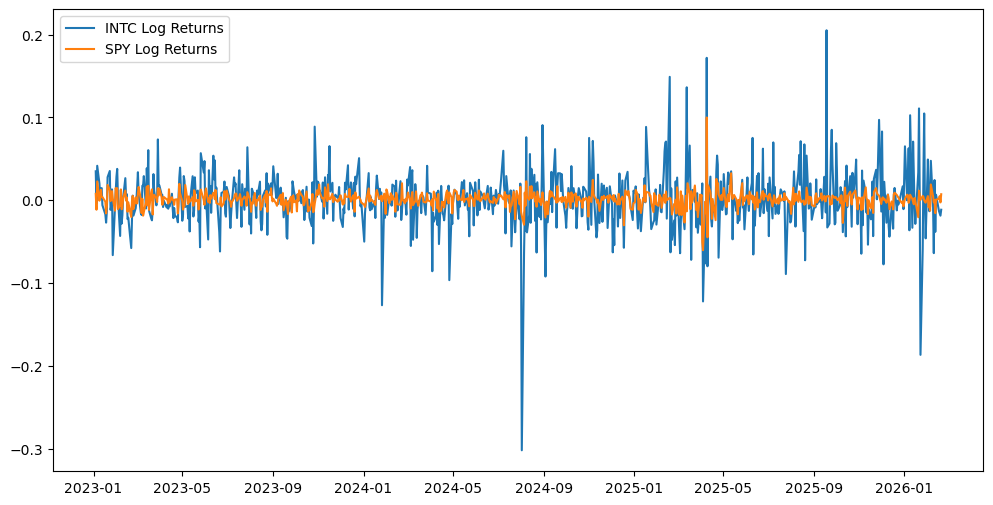

In [4]:
# plot log returns
plt.figure(figsize=(12, 6))
plt.plot(stock_log_ret, label=f'{stock} Log Returns')
plt.plot(index_log_ret, label=f'{index} Log Returns')
plt.legend()

In [17]:
# Calculation of total return, last / first - 1
stock_total_return = (stock_data['Close'].iloc[-1] / stock_data['Close'].iloc[0] - 1).item()
index_total_return = (index_data['Close'].iloc[-1] / index_data['Close'].iloc[0] - 1).item()

stock_avg_daily_return = stock_log_ret.mean().item()
index_avg_daily_return = index_log_ret.mean().item()

stock_avg_simple_daily_return = np.exp(stock_avg_daily_return) - 1
index_avg_simple_daily_return = np.exp(index_avg_daily_return) - 1

# Calculation of average annual return, mean log return * 252
stock_avg_return = (stock_avg_daily_return * 252)
index_avg_return = (index_avg_daily_return * 252)

stock_avg_simple_return_annual = np.exp(stock_avg_return) - 1
index_avg_simple_return_annual = np.exp(index_avg_return) - 1

print(f'{stock} Total Return: {stock_total_return:.2%}'
      f'\n{index} Total Return: {index_total_return:.2%}'
      f'\n{stock} Average Daily Return: {stock_avg_simple_daily_return:.4%}'
      f'\n{index} Average Daily Return: {index_avg_simple_daily_return:.4%}'
      f'\n{stock} Average Annual Return: {stock_avg_simple_return_annual:.2%}'
      f'\n{index} Average Annual Return: {index_avg_simple_return_annual:.2%}')


INTC Total Return: 71.13%
SPY Total Return: 88.33%
INTC Average Daily Return: 0.0685%
SPY Average Daily Return: 0.0807%
INTC Average Annual Return: 18.82%
SPY Average Annual Return: 22.53%


In [6]:
# Calculation of correlation between stock and index log return
rho = stock_log_ret.iloc[:, 0].corr(index_log_ret.iloc[:, 0])
print(f'Correlation between {stock} and {index}: {rho:.4f}')

Correlation between INTC and SPY: 0.4562


In [7]:
# calculate garch(1, 1) parameters
from arch import arch_model
stock_vol = arch_model(stock_log_ret.dropna(), vol='Garch', p=1, q=1, rescale=False)
index_vol = arch_model(index_log_ret.dropna(), vol='Garch', p=1, q=1, rescale=False)

# Fit GARCH model
stock_res = stock_vol.fit(disp='off')
index_res = index_vol.fit(disp='off')
print("-" * 30)
print(f'{stock} GARCH(1, 1) parameters:\n{stock_res.params}')
print("\n" + f'{stock} GARCH(1, 1) p-values:\n{stock_res.pvalues}')
print("-" * 30)
print(f'{index} GARCH(1, 1) parameters:\n{index_res.params}')
print("\n" + f'{index} GARCH(1, 1) p-values:\n{index_res.pvalues}')
print("-" * 30)

------------------------------
INTC GARCH(1, 1) parameters:
mu         -0.000022
omega       0.000401
alpha[1]    0.380171
beta[1]     0.358789
Name: params, dtype: float64

INTC GARCH(1, 1) p-values:
mu          0.985751
omega       0.000173
alpha[1]    0.104439
beta[1]     0.012617
Name: pvalues, dtype: float64
------------------------------
SPY GARCH(1, 1) parameters:
mu          0.000945
omega       0.000009
alpha[1]    0.100000
beta[1]     0.800000
Name: params, dtype: float64

SPY GARCH(1, 1) p-values:
mu           0.000000e+00
omega        0.000000e+00
alpha[1]     3.726898e-03
beta[1]     3.085435e-264
Name: pvalues, dtype: float64
------------------------------


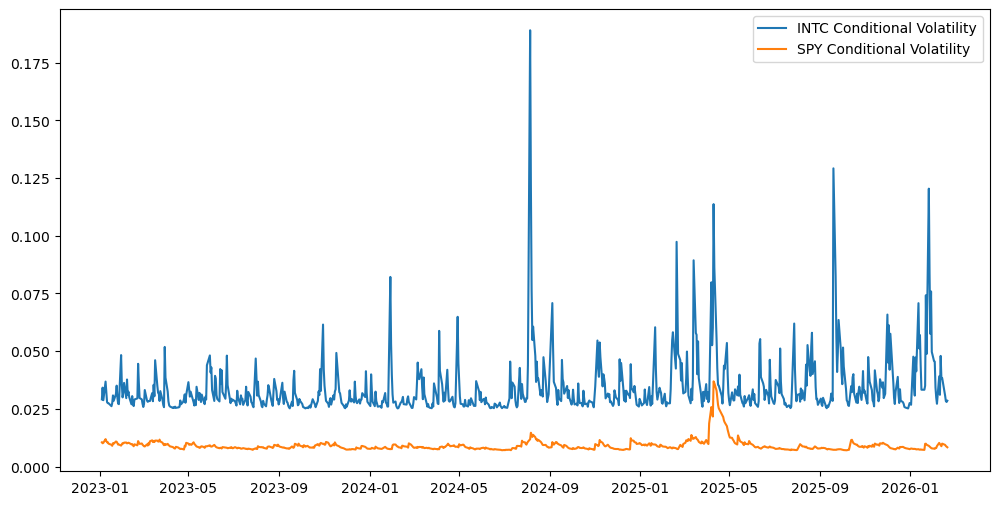

In [8]:
# plot volatility
plt.figure(figsize=(12, 6))
plt.plot(stock_res.conditional_volatility, label=f'{stock} Conditional Volatility')
plt.plot(index_res.conditional_volatility, label=f'{index} Conditional Volatility')
plt.legend()

In [9]:
# Volatility on last day of data
stock_vol_last = stock_res.conditional_volatility.iloc[-1]
index_vol_last = index_res.conditional_volatility.iloc[-1]
print("-" * 30)
print(f"{stock} Volatility on last day: {stock_vol_last:.6f}")
print(f"{index} Volatility on last day: {index_vol_last:.6f}")

# Finding volatility 3rd day after  
stock_forecast = stock_res.forecast(horizon=3)
index_forecast = index_res.forecast(horizon=3)

# Get the variance for the 3rd day 'h.3' is 3rd date in list
stock_var_t3 = stock_forecast.variance.iloc[-1]['h.3']
index_var_t3 = index_forecast.variance.iloc[-1]['h.3']

# get standard deviation
stock_vol_t3 = np.sqrt(stock_var_t3)
index_vol_t3 = np.sqrt(index_var_t3)

print("-" * 30)
print(f"{stock} Forecasted Volatility 3rd day after: {stock_vol_t3:.6f}")
print(f"{index} Forecasted Volatility 3rd day after: {index_vol_t3:.6f}")
print("-" * 30)

------------------------------
INTC Volatility on last day: 0.028532
SPY Volatility on last day: 0.008363
------------------------------
INTC Forecasted Volatility 3rd day after: 0.033211
SPY Forecasted Volatility 3rd day after: 0.008552
------------------------------


Simulating Portfolios, 1 million in stock_portfolio, 1 million in index_portfolio initially

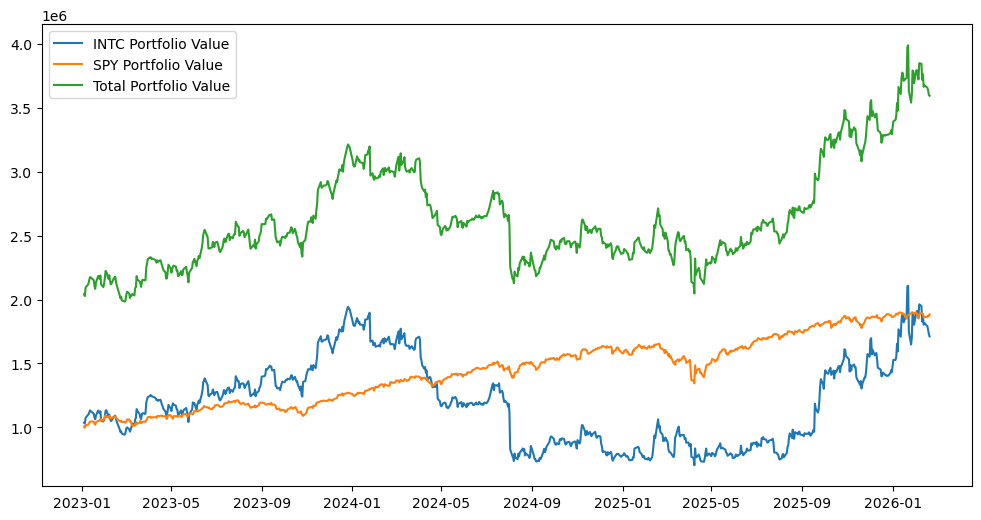

In [10]:
# Get list of all daily returns
stock_daily_returns = stock_data['Close'].pct_change().dropna().squeeze()
index_daily_returns = index_data['Close'].pct_change().dropna().squeeze()

# Initial portfolio balances
stock_portfolio = 1_000_000
index_portfolio = 1_000_000
total_portfolio = stock_portfolio + index_portfolio

# Calculate portfolio values over time
stock_portfolio_values = stock_portfolio * (1 + stock_daily_returns).cumprod()
index_portfolio_values = index_portfolio * (1 + index_daily_returns).cumprod()
total_portfolio_values = stock_portfolio_values + index_portfolio_values

# Calculate total portfolio daily returns, from values we have
total_portfolio_daily_returns = total_portfolio_values.pct_change().dropna()

plt.figure(figsize=(12, 6))
plt.plot(stock_portfolio_values, label=f'{stock} Portfolio Value')
plt.plot(index_portfolio_values, label=f'{index} Portfolio Value')
plt.plot(total_portfolio_values, label='Total Portfolio Value')
plt.legend()

In [11]:
# Setup for VaR and ES calculation
total_days = len(stock_daily_returns)
var_level = 0.99
# I have to subtract one from the int(total_days * (1 - var_level)) becuase arrays are 0 indexed
# it would have counted 1 more day than we would have wanted
var_index = max(int(total_days * (1 - var_level)) - 1, 0)

# Sort daily returns for VaR and ES calculation
stock_daily_returns_sorted = stock_daily_returns.sort_values(ascending=True)
index_daily_returns_sorted = index_daily_returns.sort_values(ascending=True)
total_portfolio_daily_returns_sorted = total_portfolio_daily_returns.sort_values(ascending=True)

# Calculate VaR
stock_portfolio_var = -1 * stock_portfolio * stock_daily_returns_sorted.iloc[var_index]
index_portfolio_var = -1 * index_portfolio * index_daily_returns_sorted.iloc[var_index]
total_portfolio_var = -1 * total_portfolio * total_portfolio_daily_returns_sorted.iloc[var_index]

print("-" * 50)
print(f"{stock} portfolio VaR at {var_level:.0%} confidence level: ${stock_portfolio_var:,.2f}")
print(f"{index} portfolio VaR at {var_level:.0%} confidence level: ${index_portfolio_var:,.2f}")
print(f"Total portfolio VaR at {var_level:.0%} confidence level: ${total_portfolio_var:,.2f}")

# Calculate diversification benefit
diversification_benefit = (stock_portfolio_var + index_portfolio_var) - total_portfolio_var
print(f"Diversification benefit: ${diversification_benefit:,.2f}")

# Calculation of ES, average of daily returns worse than the var_index
stock_portfolio_es = -1 * np.mean([stock_portfolio * ret for ret in stock_daily_returns_sorted[: var_index]])
index_portfolio_es = -1 * np.mean([index_portfolio * ret for ret in index_daily_returns_sorted[: var_index]]) 
total_portfolio_es = -1 * np.mean([total_portfolio * ret for ret in total_portfolio_daily_returns_sorted[: var_index]])

print("-" * 50)
print(f"{stock} portfolio ES at {var_level:.0%} confidence level: ${stock_portfolio_es:,.2f}")
print(f"{index} portfolio ES at {var_level:.0%} confidence level: ${index_portfolio_es:,.2f}")
print(f"Total portfolio ES at {var_level:.0%} confidence level: ${total_portfolio_es:,.2f}")
print("-" * 50)




--------------------------------------------------
INTC portfolio VaR at 99% confidence level: $85,284.95
SPY portfolio VaR at 99% confidence level: $26,635.39
Total portfolio VaR at 99% confidence level: $89,174.60
Diversification benefit: $22,745.74
--------------------------------------------------
INTC portfolio ES at 99% confidence level: $140,831.13
SPY portfolio ES at 99% confidence level: $39,599.68
Total portfolio ES at 99% confidence level: $154,994.29
--------------------------------------------------


In [12]:
vol_stock = np.sqrt(stock_forecast.variance.iloc[-1]['h.1'])
vol_index = np.sqrt(index_forecast.variance.iloc[-1]['h.1'])

# Calculate total portfolio variance in dollars
# Formula: w1^2*vol1^2 + w2^2*vol2^2 + 2*w1*w2*vol1*vol2*rho
total_portfolio_variance = (stock_portfolio**2 * vol_stock**2) + \
                  (index_portfolio**2 * vol_index**2) + \
                  (2 * stock_portfolio * index_portfolio * vol_stock * vol_index * rho)

# total portfolio volatilty
total_portfolio_volatility = np.sqrt(total_portfolio_variance)

# Get the Z-score for a 99% 
z_99 = stats.norm.ppf(0.99)

# Calculate 99% Normal VaR
normal_var_total = total_portfolio_volatility * z_99

print("-" * 50)
print(f"Total Portfolio 1-Day 99% Normal VaR: ${normal_var_total:,.2f}")
print(f"Total Portfolio 1-Day 99% Historical VaR: ${total_portfolio_var:,.2f}")

# Compare Normal VaR to Historical VaR
print("-" * 50)
if normal_var_total > total_portfolio_var:
    print("The Normal VaR approach leads to a larger VaR.")
else:
    print("The Historical Simulation approach leads to a larger VaR.")
print("-" * 50)

--------------------------------------------------
Total Portfolio 1-Day 99% Normal VaR: $74,246.10
Total Portfolio 1-Day 99% Historical VaR: $89,174.60
--------------------------------------------------
The Historical Simulation approach leads to a larger VaR.
--------------------------------------------------


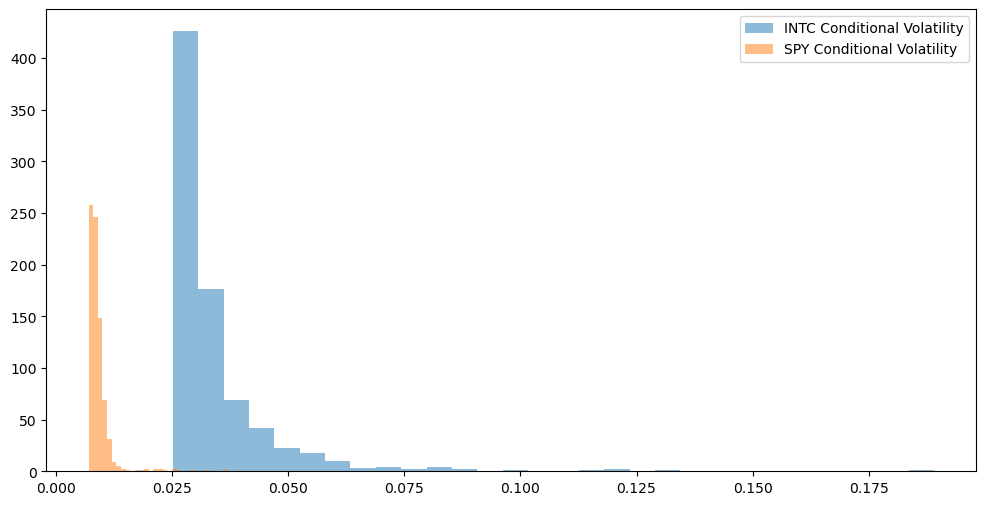

In [13]:
# Distribution of volatilites
plt.figure(figsize=(12, 6))
plt.hist(stock_res.conditional_volatility, bins=30, alpha=0.5, label=f'{stock} Conditional Volatility')
plt.hist(index_res.conditional_volatility, bins=30, alpha=0.5, label=f'{index} Conditional Volatility')
plt.legend()

In [14]:
# Expected return of the portfolio, mean log return * portfolio value
exp_return_stock = stock_avg_daily_return * stock_portfolio
exp_return_index = index_avg_daily_return * index_portfolio
exp_return_total = exp_return_stock + exp_return_index

# Economic capital
econ_capital_stock = stock_portfolio_var
econ_capital_index = index_portfolio_var
econ_capital_total = total_portfolio_var

rorac_stock = exp_return_stock / econ_capital_stock
rorac_index = exp_return_index / econ_capital_index
rorac_total = exp_return_total / econ_capital_total

print("-" * 50)
print(f"({stock}):")
print(f"  Expected 1-Day Return: ${exp_return_stock:,.2f}")
print(f"  Economic Capital (VaR): ${econ_capital_stock:,.2f}")
print(f"  RORAC: {rorac_stock:.6f}")
print("-" * 50)

print(f"({index}):")
print(f"  Expected 1-Day Return: ${exp_return_index:,.2f}")
print(f"  Economic Capital (VaR): ${econ_capital_index:,.2f}")
print(f"  RORAC: {rorac_index:.6f}")
print("-" * 50)

print(f"(Total Portfolio):")
print(f"  Expected 1-Day Return: ${exp_return_total:,.2f}")
print(f"  Economic Capital (VaR): ${econ_capital_total:,.2f}")
print(f"  RORAC: {rorac_total:.6f}")
print("-" * 50)

--------------------------------------------------
(INTC):
  Expected 1-Day Return: $684.43
  Economic Capital (VaR): $85,284.95
  RORAC: 0.008025
--------------------------------------------------
(SPY):
  Expected 1-Day Return: $806.42
  Economic Capital (VaR): $26,635.39
  RORAC: 0.030276
--------------------------------------------------
(Total Portfolio):
  Expected 1-Day Return: $1,490.85
  Economic Capital (VaR): $89,174.60
  RORAC: 0.016718
--------------------------------------------------
